In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.filterwarnings("ignore")

In [96]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


* id: Unique ID for the customer
* Gender: Gender of the customer
* Age: Age of the customer
* Driving_License: [0 : Customer does not have DL, 1 : Customer already has DL]
* Region_Code: Unique code for the region of the customer
* Previously_Insured: [1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance]
* Vehicle_Age: Age of the Vehicle
* Vehicle_Damage: [1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.]
* Annual_Premium: The amount customer needs to pay as premium in the year
* Policy_Sales_Channel: Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.
* Vintage: Number of Days, Customer has been associated with the company
* Response: [1 : Customer is interested, 0 : Customer is not interested]

## EDA

In [97]:
df.shape

(381109, 12)

In [98]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [100]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [101]:
# checking distribution for target column
df['Response'].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

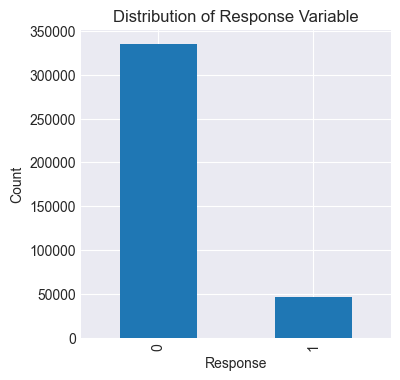

In [102]:
plt.figure(figsize=(4,4))
df['Response'].value_counts().plot(kind='bar')
plt.title('Distribution of Response Variable')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

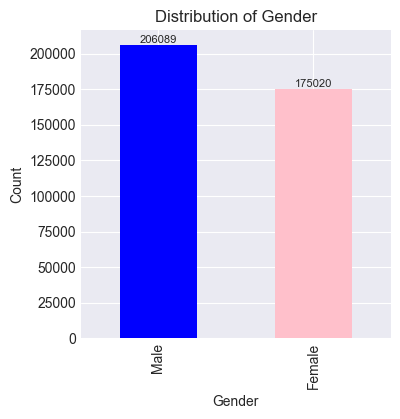

In [103]:
# gender distribution
plt.figure(figsize=(4,4))
df.Gender.value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
for index, value in enumerate(df.Gender.value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=8)
plt.show()

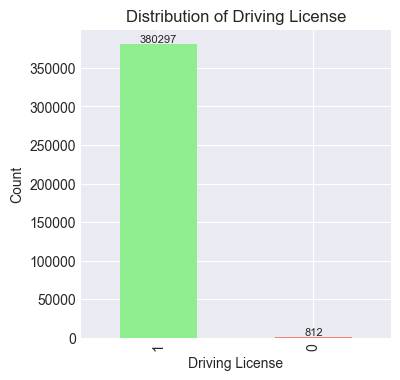

In [104]:
# driving license distribution
plt.figure(figsize=(4,4))
df.Driving_License.value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribution of Driving License')
plt.xlabel('Driving License')
plt.ylabel('Count')
for index, value in enumerate(df.Driving_License.value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=8)
plt.show()

Skewnness of Age: 0.6725389977260843


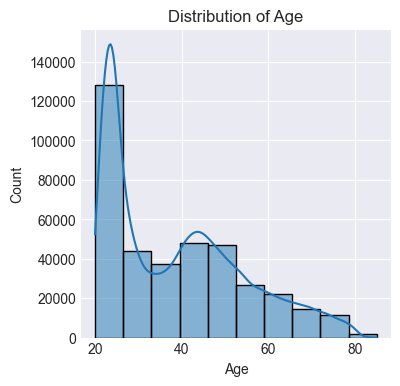

Age
(19.935, 26.5]    128040
(39.5, 46.0]       55767
(26.5, 33.0]       48941
(46.0, 52.5]       38847
(33.0, 39.5]       32475
(52.5, 59.0]       30266
(59.0, 65.5]       18704
(65.5, 72.0]       16754
(72.0, 78.5]        9362
(78.5, 85.0]        1953
Name: count, dtype: int64

In [105]:
# Age distribution
plt.figure(figsize=(4,4))
sns.histplot(df.Age, bins=10, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
print("Skewnness of Age:", df['Age'].skew())
plt.show()
pd.cut(df['Age'], bins=10).value_counts()

skewness after Power Transformation: 0.06538539733695828


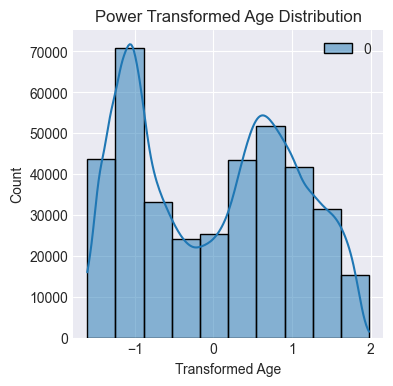

In [106]:
# Power Transformation of Age
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
temp_age = pt.fit_transform(df[['Age']])
plt.figure(figsize=(4,4))
sns.histplot(temp_age, bins=10, kde=True, color='orange')
plt.title('Power Transformed Age Distribution')
plt.xlabel('Transformed Age')
plt.ylabel('Count')
print("skewness after Power Transformation:", pd.Series(temp_age.flatten()).skew())
plt.show()

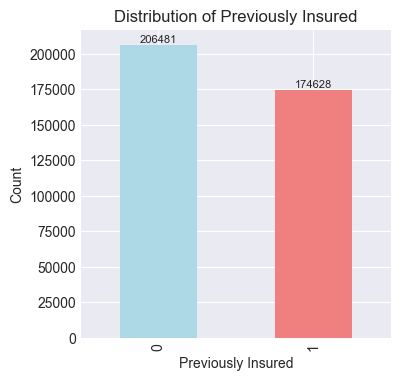

In [107]:
plt.figure(figsize=(4,4))
df.Previously_Insured.value_counts().plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Distribution of Previously Insured')
plt.xlabel('Previously Insured')
plt.ylabel('Count')
for index, value in enumerate(df.Previously_Insured.value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=8)
plt.show()

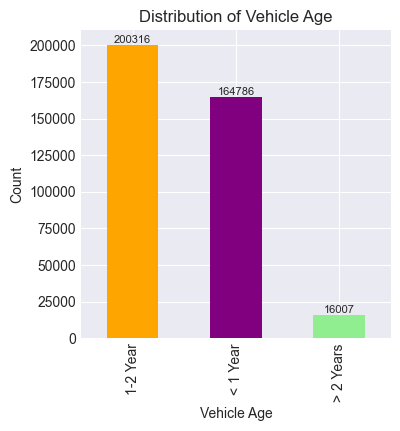

In [108]:
df.Vehicle_Age.value_counts()
plt.figure(figsize=(4,4))
df.Vehicle_Age.value_counts().plot(kind='bar', color=['orange', 'purple', 'lightgreen'])
plt.title('Distribution of Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
for index, value in enumerate(df.Vehicle_Age.value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=8)
plt.show()

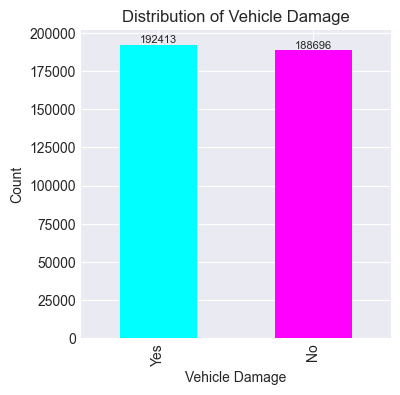

In [109]:
df.Vehicle_Damage.value_counts()
plt.figure(figsize=(4,4))
df.Vehicle_Damage.value_counts().plot(kind='bar', color=['cyan', 'magenta'])
plt.title('Distribution of Vehicle Damage')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
for index, value in enumerate(df.Vehicle_Damage.value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=8)

In [110]:
df.Annual_Premium.describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

Skewness:  1.7660872148961309


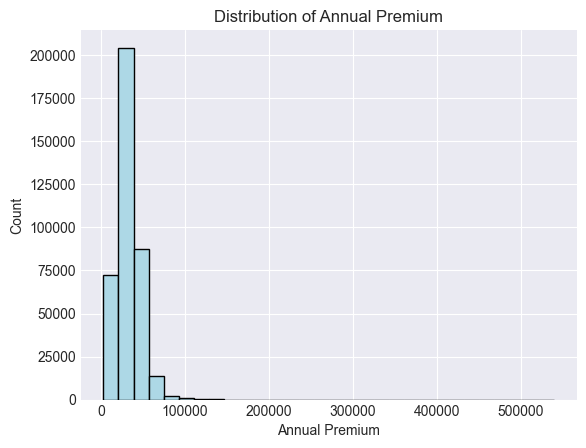

In [111]:
df.Annual_Premium.hist(bins=30, color='lightblue', edgecolor='black')
plt.title('Distribution of Annual Premium')
plt.xlabel('Annual Premium')
plt.ylabel('Count')
print("Skewness: ",df.Annual_Premium.skew())
plt.show()

skewness after Power Transformation: 0.08322090962265719


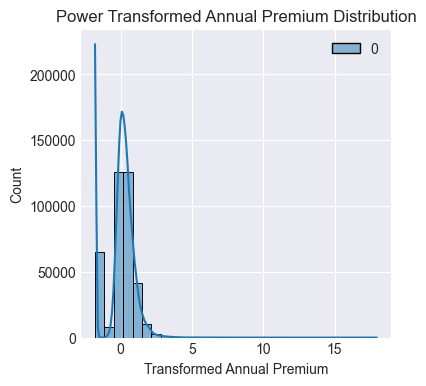

In [112]:
# Power Transformation of Annual Premium
temp_premium = pt.fit_transform(df[['Annual_Premium']])
plt.figure(figsize=(4,4))
sns.histplot(temp_premium, bins=30, kde=True, color='lightgreen')
plt.title('Power Transformed Annual Premium Distribution')
plt.xlabel('Transformed Annual Premium')
plt.ylabel('Count')
print("skewness after Power Transformation:", pd.Series(temp_premium.flatten()).skew())
plt.show()

In [113]:
pd.set_option('display.max_rows', None)
df.Policy_Sales_Channel.value_counts()

Policy_Sales_Channel
152.0    134784
26.0      79700
124.0     73995
160.0     21779
156.0     10661
122.0      9930
157.0      6684
154.0      5993
151.0      3885
163.0      2893
13.0       1865
25.0       1848
7.0        1598
8.0        1515
30.0       1410
55.0       1264
155.0      1234
11.0       1203
1.0        1074
52.0       1055
125.0      1026
15.0        888
29.0        843
12.0        783
120.0       769
24.0        750
31.0        631
14.0        622
153.0       607
61.0        579
3.0         523
16.0        523
60.0        517
4.0         509
158.0       492
23.0        422
22.0        332
150.0       312
10.0        264
19.0        222
136.0       185
147.0       184
109.0       175
145.0       174
9.0         169
18.0        167
91.0        158
116.0       154
37.0        152
21.0        148
139.0       143
128.0       137
42.0        132
59.0        127
138.0       124
131.0       121
127.0       110
140.0       107
113.0       104
119.0       103
44.0        101
135

In [114]:
df.Vintage.describe()

count    381109.000000
mean        154.347397
std          83.671304
min          10.000000
25%          82.000000
50%         154.000000
75%         227.000000
max         299.000000
Name: Vintage, dtype: float64

Text(0.5, 0, 'Vintage')

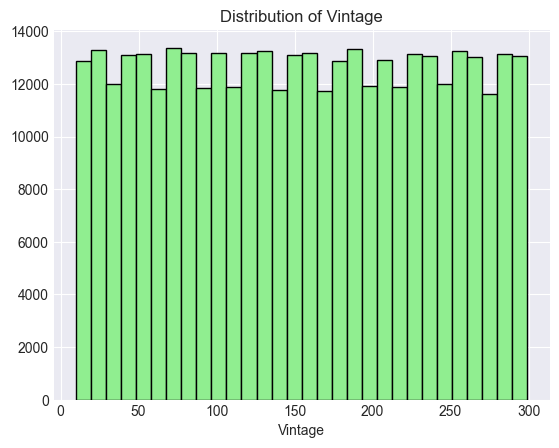

In [115]:
df.Vintage.hist(bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Vintage')
plt.xlabel('Vintage')

## Bivariate Analysis

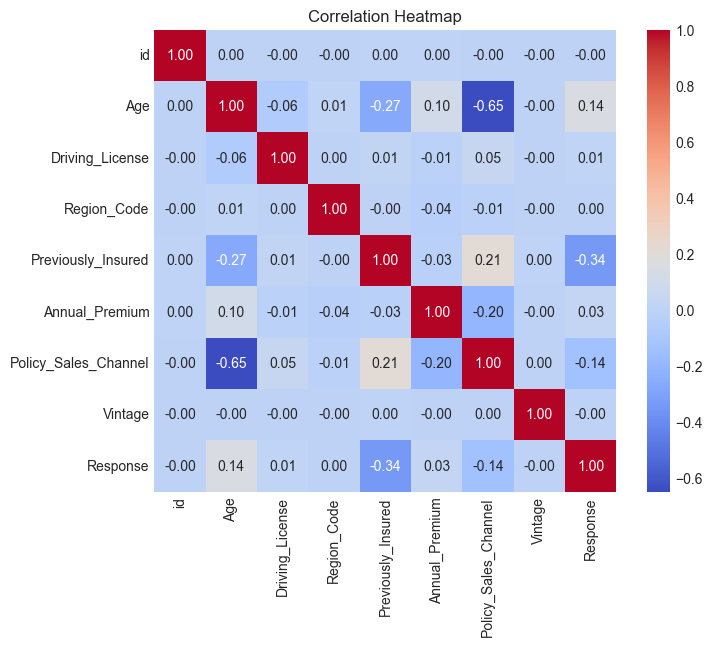

In [116]:
# Correlation Heatmap

# numerical features correlation
nums = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(nums.corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

### Gender vs Other

Text(0.5, 0, 'Gender')

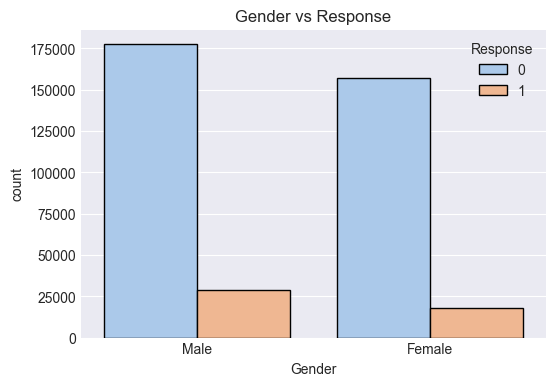

In [117]:
# Gender and Response
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Response', data=df, palette='pastel', edgecolor='black')
plt.title('Gender vs Response')
plt.xlabel('Gender')

Text(0.5, 1.0, 'Gender vs Annual Premium')

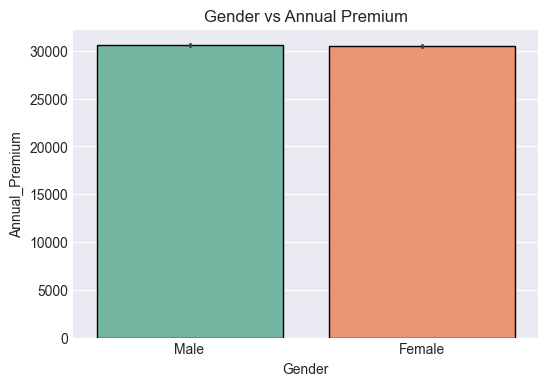

In [118]:
# Gender and Annual Premium
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Annual_Premium', data=df, palette='Set2', edgecolor='black')
plt.title('Gender vs Annual Premium')

Text(0, 0.5, 'Count')

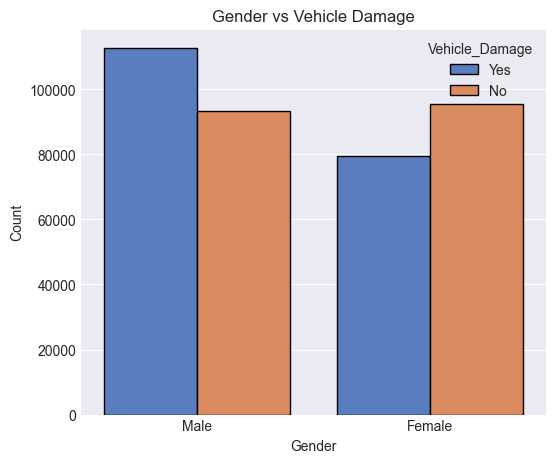

In [119]:
# Gender and Vehicle Damage
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', hue='Vehicle_Damage', data=df, palette='muted', edgecolor='black')
plt.title('Gender vs Vehicle Damage')
plt.xlabel('Gender')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

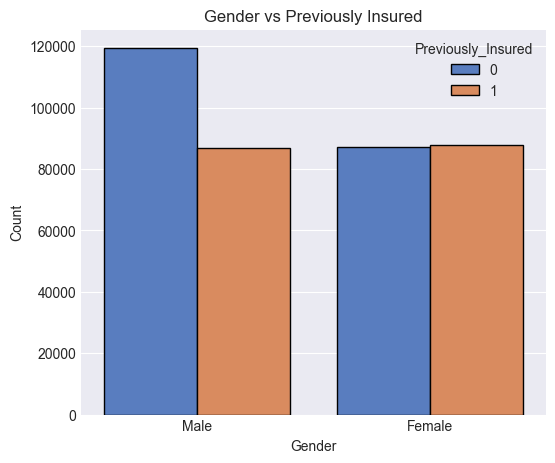

In [120]:
# Gender and Previously Insured
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', hue='Previously_Insured', data=df, palette='muted', edgecolor='black')
plt.title('Gender vs Previously Insured')
plt.xlabel('Gender')
plt.ylabel('Count')

Text(0, 0.5, 'Average Vintage')

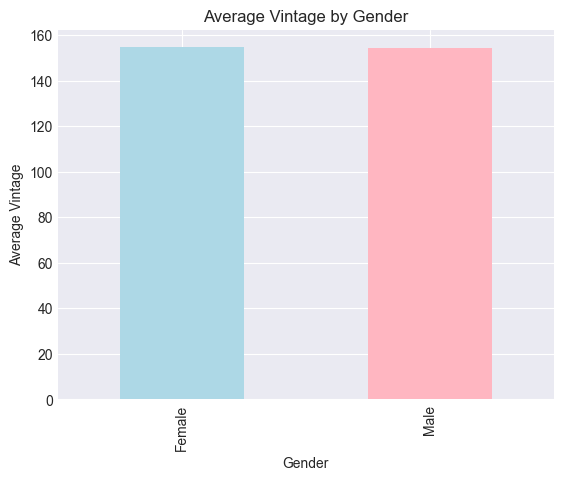

In [121]:
df.groupby('Gender')['Vintage'].mean().plot(kind='bar', color=['lightblue', 'lightpink'])
plt.title('Average Vintage by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Vintage')

### Age vs Other

Text(0, 0.5, 'Vintage')

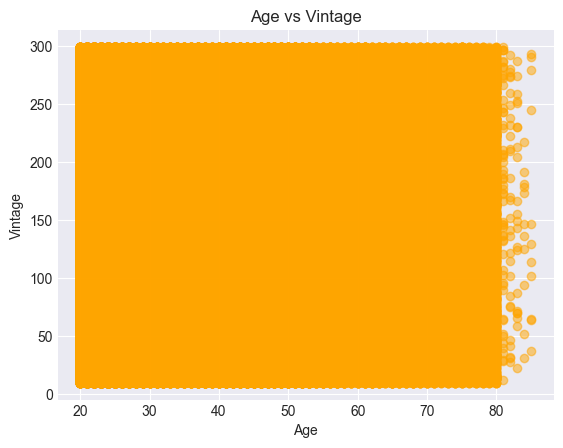

In [122]:
# Age vs Vintage
plt.scatter(df.Age, df.Vintage, alpha=0.5, color='orange')
plt.title('Age vs Vintage')
plt.xlabel('Age')
plt.ylabel('Vintage')

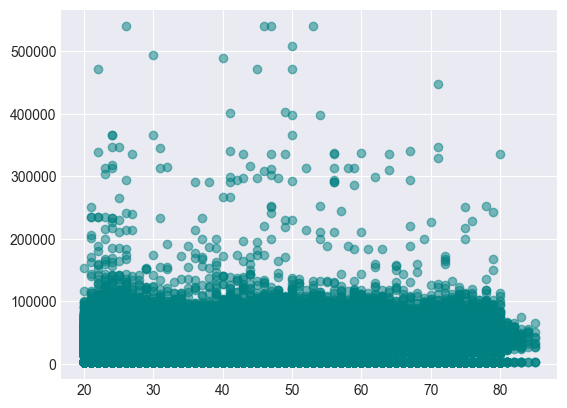

In [123]:
# Age vs Annual premium

plt.scatter(df.Age, df.Annual_Premium, alpha=0.5, color='teal')

Text(0, 0.5, 'Count')

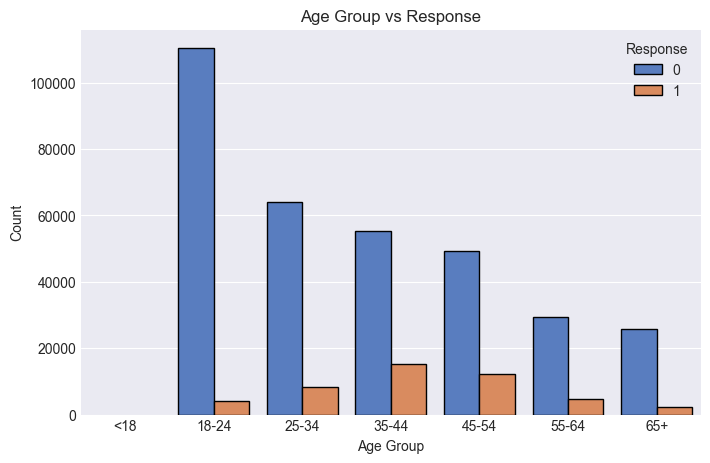

In [124]:
# Age group vs Response
age_bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
# Age and Response
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', hue='Response', data=df, palette='muted', edgecolor='black')
plt.title('Age Group vs Response')
plt.xlabel('Age Group')
plt.ylabel('Count')

Text(0.5, 1.0, 'Age Group vs Response Rate')

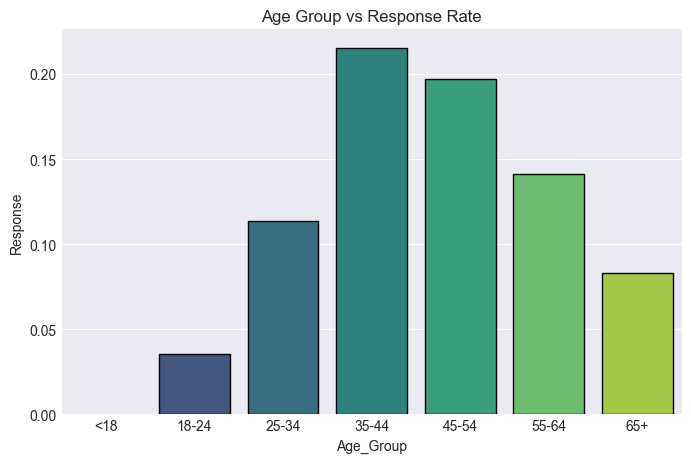

In [125]:
# Age group and Response rate
age_response = df.groupby('Age_Group')['Response'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Group', y='Response', data=age_response, palette='viridis', edgecolor='black')
plt.title('Age Group vs Response Rate')

Text(0, 0.5, 'Count')

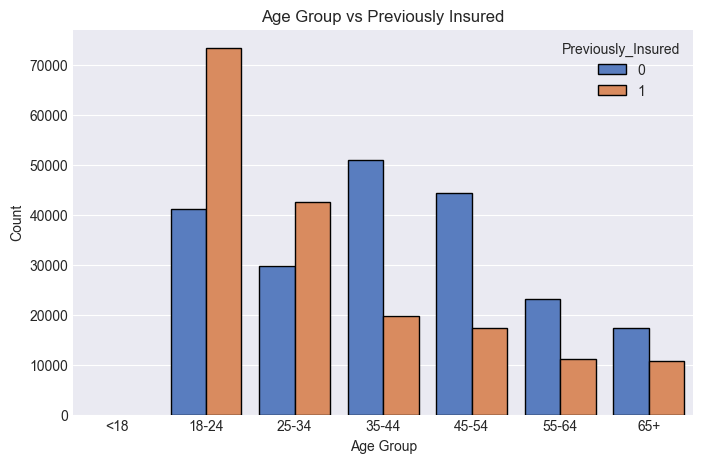

In [126]:
# Age and Previously Insured rate

plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', hue='Previously_Insured', data=df, palette='muted', edgecolor='black')
plt.title('Age Group vs Previously Insured')
plt.xlabel('Age Group')
plt.ylabel('Count')

In [127]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response', 'Age_Group'],
      dtype='object')

Text(0, 0.5, 'Count')

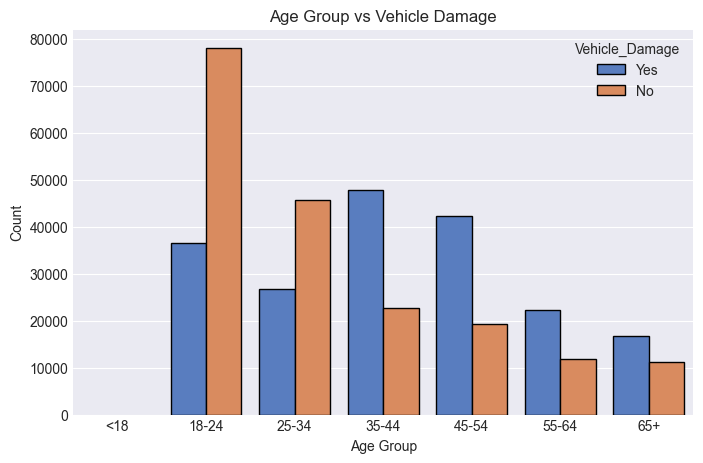

In [128]:
# Age vs Vehicle Damage
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Group', hue='Vehicle_Damage', data=df, palette='muted', edgecolor='black')
plt.title('Age Group vs Vehicle Damage')
plt.xlabel('Age Group')
plt.ylabel('Count')

### Vehicle age and Others

Text(0, 0.5, 'Response')

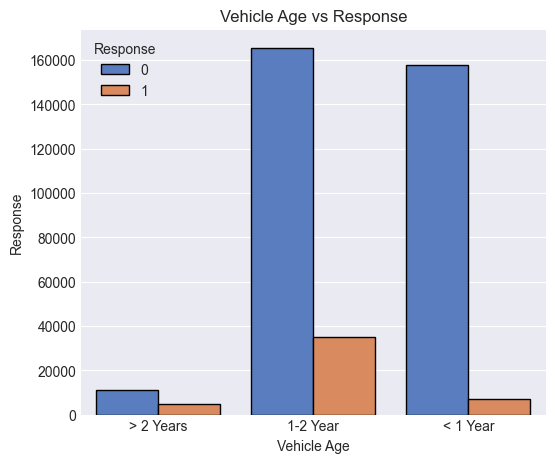

In [129]:
# vehicle age vs Response
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Age', hue='Response', data=df, palette='muted', edgecolor='black')
plt.title('Vehicle Age vs Response')
plt.xlabel('Vehicle Age')
plt.ylabel('Response')

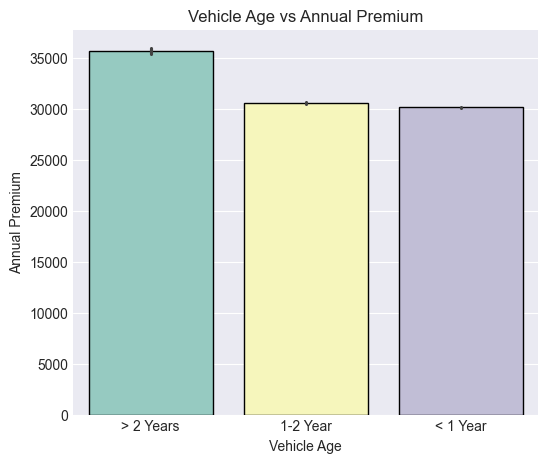

In [130]:
# vehicle age vs Annual Premium
plt.figure(figsize=(6,5))
sns.barplot(x='Vehicle_Age', y='Annual_Premium', data=df, palette='Set3', edgecolor='black')
plt.title('Vehicle Age vs Annual Premium')
plt.xlabel('Vehicle Age')
plt.ylabel('Annual Premium')
plt.show()

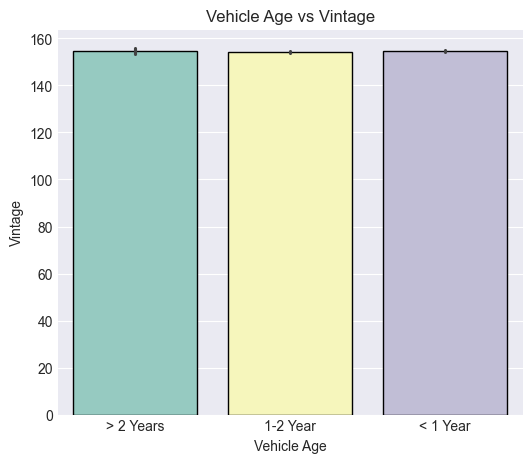

In [131]:
# vehicle age vs Vintage
plt.figure(figsize=(6,5))
sns.barplot(x='Vehicle_Age', y='Vintage', data=df, palette='Set3', edgecolor='black')
plt.title('Vehicle Age vs Vintage')
plt.xlabel('Vehicle Age')
plt.ylabel('Vintage')
plt.show()


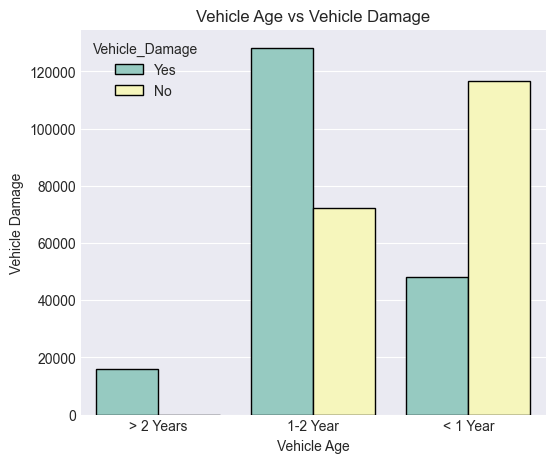

In [132]:
# vehicle age vs vehicle damage
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Age', hue='Vehicle_Damage', data=df, palette='Set3', edgecolor='black')
plt.title('Vehicle Age vs Vehicle Damage')
plt.xlabel('Vehicle Age')
plt.ylabel('Vehicle Damage')
plt.show()


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    381109 non-null  int64   
 1   Gender                381109 non-null  object  
 2   Age                   381109 non-null  int64   
 3   Driving_License       381109 non-null  int64   
 4   Region_Code           381109 non-null  float64 
 5   Previously_Insured    381109 non-null  int64   
 6   Vehicle_Age           381109 non-null  object  
 7   Vehicle_Damage        381109 non-null  object  
 8   Annual_Premium        381109 non-null  float64 
 9   Policy_Sales_Channel  381109 non-null  float64 
 10  Vintage               381109 non-null  int64   
 11  Response              381109 non-null  int64   
 12  Age_Group             381109 non-null  category
dtypes: category(1), float64(3), int64(6), object(3)
memory usage: 35.3+ MB


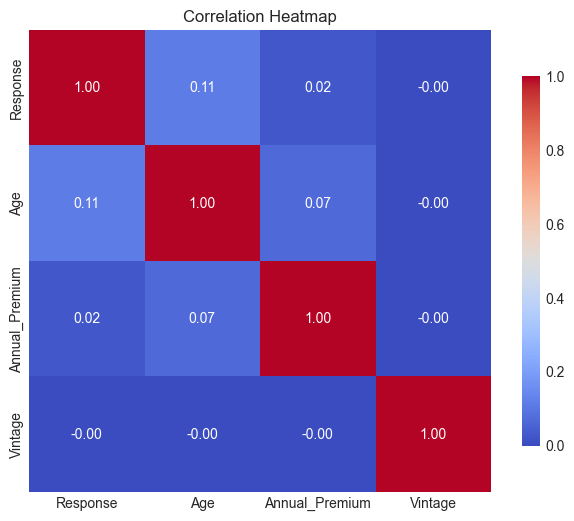

In [134]:
# correlation between response and other numerical features
plt.figure(figsize=(8,6))
corr = df[['Response', 'Age', 'Annual_Premium', 'Vintage']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    381109 non-null  int64   
 1   Gender                381109 non-null  object  
 2   Age                   381109 non-null  int64   
 3   Driving_License       381109 non-null  int64   
 4   Region_Code           381109 non-null  float64 
 5   Previously_Insured    381109 non-null  int64   
 6   Vehicle_Age           381109 non-null  object  
 7   Vehicle_Damage        381109 non-null  object  
 8   Annual_Premium        381109 non-null  float64 
 9   Policy_Sales_Channel  381109 non-null  float64 
 10  Vintage               381109 non-null  int64   
 11  Response              381109 non-null  int64   
 12  Age_Group             381109 non-null  category
dtypes: category(1), float64(3), int64(6), object(3)
memory usage: 35.3+ MB


In [136]:
# Dealing Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Vehicle_Damage'] = le.fit_transform(df['Vehicle_Damage'])


In [137]:
df.Vehicle_Age.value_counts()

Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64

In [138]:
# very less values in vehicle age greate then 2 years
# so make only 2 values either greater or less then 1 years

df['Vehicle_Age > 1 yr'] = df['Vehicle_Age'].replace({'1-2 Year':1, '> 2 Years':1, '< 1 Year':0})

In [139]:
# Drop Vehicle_Age
df.drop(columns = 'Vehicle_Age', inplace=True)

In [140]:
# Drop Driving License very few data with no license
print(df.Driving_License.value_counts())

df.drop(columns = 'Driving_License', inplace = True)

Driving_License
1    380297
0       812
Name: count, dtype: int64


In [141]:
df.Policy_Sales_Channel.value_counts()


Policy_Sales_Channel
152.0    134784
26.0      79700
124.0     73995
160.0     21779
156.0     10661
122.0      9930
157.0      6684
154.0      5993
151.0      3885
163.0      2893
13.0       1865
25.0       1848
7.0        1598
8.0        1515
30.0       1410
55.0       1264
155.0      1234
11.0       1203
1.0        1074
52.0       1055
125.0      1026
15.0        888
29.0        843
12.0        783
120.0       769
24.0        750
31.0        631
14.0        622
153.0       607
61.0        579
3.0         523
16.0        523
60.0        517
4.0         509
158.0       492
23.0        422
22.0        332
150.0       312
10.0        264
19.0        222
136.0       185
147.0       184
109.0       175
145.0       174
9.0         169
18.0        167
91.0        158
116.0       154
37.0        152
21.0        148
139.0       143
128.0       137
42.0        132
59.0        127
138.0       124
131.0       121
127.0       110
140.0       107
113.0       104
119.0       103
44.0        101
135

- many policy channels with very less counts
- Assign Policy channels less then 500 counts to one specific channel

In [142]:
temp = pd.Series(df['Policy_Sales_Channel'].value_counts())
indextemp = temp[pd.Series(df['Policy_Sales_Channel'].value_counts() < 500)].index
df.Policy_Sales_Channel = df.Policy_Sales_Channel.replace(indextemp, indextemp[0])

In [143]:
df.head()

,id,Gender,Age,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Vehicle_Age > 1 yr
0,1,1,44,28.0,0,1,40454.0,26.0,217,1,35-44,1
1,2,1,76,3.0,0,0,33536.0,26.0,183,0,65+,1
2,3,1,47,28.0,0,1,38294.0,26.0,27,1,45-54,1
3,4,1,21,11.0,1,0,28619.0,152.0,203,0,18-24,0
4,5,0,29,41.0,1,0,27496.0,152.0,39,0,25-34,0


In [144]:
# Age and Annual Premium fix skewness
from sklearn.preprocessing import PowerTransformer
pf = PowerTransformer()

df['Age'] = pf.fit_transform(df[['Age']])
df['Annual_Premium'] = pf.fit_transform(df[['Annual_Premium']])

In [145]:
df.head()

,id,Gender,Age,Region_Code,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Age_Group,Vehicle_Age > 1 yr
0,1,1,0.571865,28.0,0,1,0.612207,26.0,217,1,35-44,1
1,2,1,1.765186,3.0,0,0,0.243028,26.0,183,0,65+,1
2,3,1,0.728579,28.0,0,1,0.498645,26.0,27,1,45-54,1
3,4,1,-1.452684,11.0,1,0,-0.030214,152.0,203,0,18-24,0
4,5,0,-0.506661,41.0,1,0,-0.094107,152.0,39,0,25-34,0


In [167]:
X = df.drop(columns=['id', 'Age_Group', 'Response', 'Region_Code'])
y = df.Response

In [168]:
X.head()

,Gender,Age,Previously_Insured,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Vehicle_Age > 1 yr
0,1,0.571865,0,1,0.612207,26.0,217,1
1,1,1.765186,0,0,0.243028,26.0,183,1
2,1,0.728579,0,1,0.498645,26.0,27,1
3,1,-1.452684,1,0,-0.030214,152.0,203,0
4,0,-0.506661,1,0,-0.094107,152.0,39,0


In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [170]:
# Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [174]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [171]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [ ]:
# Train and evaluate models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Complement Naive Bayes": ComplementNB(),
    "Berouli Naive Bayes": BernoulliNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for model_name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"Precision: {precision_score(y_test, y_pred)}")
    print(f"Recall: {recall_score(y_test, y_pred)}")
    print(f"F1 Score: {f1_score(y_test, y_pred)}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred)}")
    print()
    print('-'*40)

Model: Logistic Regression
Accuracy: 0.639566004565611
Precision: 0.2505983658422515
Recall: 0.9750588739028045
F1 Score: 0.39872184894180474
ROC AUC: 0.7838811115925506

----------------------------------------
Model: Complement Naive Bayes
Accuracy: 0.606399727112907
Precision: 0.23612211010346149
Recall: 0.9894026974951831
F1 Score: 0.38125683172809205
ROC AUC: 0.7711517075992662

----------------------------------------
Model: Berouli Naive Bayes
Accuracy: 0.6475951824932434
Precision: 0.25464272709447916
Recall: 0.9731320916292014
F1 Score: 0.4036587261061652
ROC AUC: 0.7876276486854141

----------------------------------------
Model: KNN
Accuracy: 0.7503214295085409
Precision: 0.2727187426694816
Recall: 0.6222436309141511
F1 Score: 0.3792282349871155
ROC AUC: 0.6952276767010948

----------------------------------------
Model: Decision Tree
Accuracy: 0.8081525019023379
Precision: 0.27692827574554363
Recall: 0.3508884607150503
F1 Score: 0.3095519146324189
ROC AUC: 0.611456491123075